# mmBERT INT8 Quantization with SmoothQuant

**Author**: kj
**Pipeline stage**: 0 - model preparation (quantize the statement encoder)

This notebook post-training-quantizes **any mmBERT checkpoint** (`jhu-clsp/mmBERT-base`/`-small` or a fine-tuned derivative, Hub id or local path) to **INT8 (W8A8)** with **SmoothQuant**, then materializes the chosen configuration as a real, deployable **OpenVINO INT8** model. Set `MODEL_NAME` to point at whichever checkpoint to quantize; SmoothQuant folds into the shared ModernBERT `LayerNorm → Linear` structure, so every mmBERT variant works the same way.

mmBERT is the statement encoder for the document-distance pipeline; an INT8 encoder cuts memory and latency, but only if it preserves the relative similarities that optimal transport depends on - so the notebook is built around a *quality verdict*, measured by correlation against the FP32 baseline on the project's own statements.

The notebook has two parts. **Part A** finds the best quant configuration by PyTorch fake-quant simulation on GPU - cheap to iterate. **Part B** deploys that configuration for real with OpenVINO + NNCF on CPU and confirms the deployed model keeps the fidelity the simulation predicted.

## Approach
1. **Baseline (FP32)** - embed an evaluation corpus, record the pairwise cosine-similarity structure - the reference every INT8 variant is judged against
2. **Activation scheme** - compare per-tensor vs per-token dynamic INT8 activations, with and without SmoothQuant; per-token is the canonical W8A8 scheme
3. **Alpha sweep** - tune the SmoothQuant migration strength and pick the value that maximizes in-domain Pearson
4. **Per-component ablation** - quantize one projection type at a time to find which hurts most; the un-smoothed `attn.Wo` / `mlp.Wo` are the suspects, driving a mixed-precision decision
5. **Deploy (OpenVINO INT8)** - export and NNCF-quantize with SmoothQuant at the chosen alpha, then verify and benchmark the real INT8 model

> ModernBERT caveat: `config.reference_compile = False` and `attn_implementation="eager"` avoid the first-forward `torch.compile` hang.

## Outputs
- `reports/00-mmbert-int8-smoothquant-metrics.json` - full ablation + deployment metrics
- `reports/00-mmbert-bestconfig.json` - the chosen quant configuration
- `models/00-mmbert-openvino-int8/` - deployable OpenVINO INT8 IR
- In-notebook quality tables, an alpha-sweep plot, and a latency/size benchmark

## GPU Selection

Selects the **RTX 5000 Ada** (nvidia-smi index 2, compute 8.9, 32 GB) over the Blackwell 5090 to avoid new-architecture kernel risk. `CUDA_DEVICE_ORDER=PCI_BUS_ID` aligns torch's order with nvidia-smi, and the env vars are set BEFORE any torch import so the isolation takes effect.

In [1]:
import os

os.environ["CUDA_DEVICE_ORDER"] = "PCI_BUS_ID"
os.environ["CUDA_VISIBLE_DEVICES"] = "2"        # RTX 5000 Ada (nvidia-smi index)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

## Imports

All Part A imports grouped by purpose. `scipy.stats` provides the correlation metrics; SmoothQuant and INT8 fake-quantization are implemented inline so the quality measurement is transparent. The OpenVINO/NNCF imports used by Part B are loaded later, inside that section, since they are a heavier optional stack.

In [2]:
%load_ext autoreload
%autoreload 2

# Standard library
import copy
import json
import time
from pathlib import Path

# Numerics
import numpy as np
import polars as pl
from scipy.stats import pearsonr, spearmanr

# Plotting
import matplotlib.pyplot as plt

# Deep learning
import torch
import torch.nn as nn
import torch.nn.functional as F
from transformers import AutoConfig, AutoModel, AutoTokenizer

# Rich console output
from rich import print as rprint
from rich.console import Console
from rich.table import Table

console = Console()

## Reproducibility

Quantization here is deterministic given the calibration set, but the seeds are pinned so any future sampling of calibration data stays reproducible.

In [3]:
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Configuration

Model, quantization, and path settings. `ALPHAS` is the SmoothQuant sweep range - the migration strength `act^alpha / weight^(1-alpha)`; the best value is chosen in Part A. Default activation quant is **per-token dynamic** INT8 (each token row gets its own scale), the canonical SmoothQuant W8A8 scheme; weights are **per-channel symmetric** INT8.

In [4]:
# Model - any mmBERT checkpoint: original or fine-tuned, HF Hub id or local path
MODEL_NAME = "jhu-clsp/mmBERT-base"   # e.g. "jhu-clsp/mmBERT-small" or "/path/to/finetuned-mmbert"
MAX_LEN = 128
EMBED_BATCH = 16

# Quantization
ALPHA = 0.5                                  # default SmoothQuant strength (scheme comparison)
ALPHAS = [0.4, 0.5, 0.6, 0.7, 0.8]           # sweep range
ACT_MODE = "per_token"                        # default activation quant: per_token | per_tensor
QUANT_TARGETS = ("attn.Wqkv", "attn.Wo", "mlp.Wi", "mlp.Wo")
SMOOTH_PAIRS = (("attn_norm", "attn.Wqkv"), ("mlp_norm", "mlp.Wi"))

# Paths
PROJ_ROOT = Path.cwd().parent
STMT_PATH = PROJ_ROOT / "data" / "interim" / "01-statements.parquet"   # in-domain corpus (from nb 01)
METRICS_PATH = PROJ_ROOT / "reports" / "00-mmbert-int8-smoothquant-metrics.json"
BESTCFG_PATH = PROJ_ROOT / "reports" / "00-mmbert-bestconfig.json"
OV_DIR = PROJ_ROOT / "models" / "00-mmbert-openvino-int8"

# Device - resolved at runtime; GPU info shown in render below
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A"
gpu_compute_cap = (
    f"{torch.cuda.get_device_properties(0).major}.{torch.cuda.get_device_properties(0).minor}"
    if torch.cuda.is_available() else "N/A"
)
gpu_memory_gb = (
    torch.cuda.get_device_properties(0).total_memory / 1e9 if torch.cuda.is_available() else 0
)

rprint(f"""[bold medium_purple]Configuration[/bold medium_purple]
[dim]{"─" * 44}[/dim]
[bold slate_blue1]Model[/bold slate_blue1]
  Name: [cadet_blue]{MODEL_NAME}[/cadet_blue]
  Max length: [dark_sea_green]{MAX_LEN}[/dark_sea_green]

[bold slate_blue1]Quantization[/bold slate_blue1]
  Weights: [grey70]per-channel symmetric INT8[/grey70]
  Activations: [grey70]{ACT_MODE} dynamic INT8[/grey70]
  Alpha sweep: [dark_sea_green]{ALPHAS}[/dark_sea_green]
  Targets: [grey70]{", ".join(QUANT_TARGETS)}[/grey70]

[bold slate_blue1]Device[/bold slate_blue1]
  Using: [dark_sea_green]{device}[/dark_sea_green]
  GPU: [cadet_blue]{gpu_name}[/cadet_blue]
  Compute cap: [dark_sea_green]{gpu_compute_cap}[/dark_sea_green]
  Memory: [light_sea_green]{gpu_memory_gb:.1f} GB[/light_sea_green]
""")

Configuration
────────────────────────────────────────────
Model
  Name: jhu-clsp/mmBERT-base
  Max length: 128

Quantization
  Weights: per-channel symmetric INT8
  Activations: per_token dynamic INT8
  Alpha sweep: [0.4, 0.5, 0.6, 0.7, 0.8]
  Targets: attn.Wqkv, attn.Wo, mlp.Wi, mlp.Wo

Device
  Using: cuda
  GPU: NVIDIA RTX 5000 Ada Generation
  Compute cap: 8.9
  Memory: 34.4 GB

## Evaluation and Calibration Corpora

Two corpora drive the study. The **synthetic** set is arranged in paraphrase clusters (including a cross-lingual pair) so the pairwise similarities carry structure. The **in-domain** set is the real statements produced by notebook 01 (`data/interim/01-statements.parquet`) - the distribution the encoder actually sees in this pipeline - split into disjoint evaluation and calibration halves. If the parquet is absent the notebook falls back to the synthetic corpus for both, so stage 0 still runs standalone.

In [5]:
EVAL_SENTENCES = [
    "The stock market rose sharply today.",
    "Equities climbed steeply during the trading session.",
    "The cat slept on the warm windowsill.",
    "A feline napped by the sunny window.",
    "Researchers discovered a new species of frog.",
    "Scientists identified a previously unknown frog.",
    "The recipe calls for two cups of flour.",
    "You need two cups of flour for this dish.",
    "Quarterly revenue exceeded analyst expectations.",
    "The company beat its revenue forecast this quarter.",
    "El gato duerme junto a la ventana.",
    "Le chat dort pres de la fenetre.",
    "Photosynthesis converts sunlight into chemical energy.",
    "The marathon route winds through the old town.",
    "Bitcoin prices fluctuated wildly overnight.",
    "The orchestra tuned their instruments before the concert.",
    "Heavy rain flooded several coastal villages.",
    "The new smartphone features a faster processor.",
    "Volunteers planted trees along the river bank.",
    "The museum unveiled a rare medieval manuscript.",
    "Interest rates were left unchanged by the central bank.",
    "A solar eclipse will be visible next month.",
    "The chef garnished the plate with fresh basil.",
    "Engineers tested the bridge for structural fatigue.",
    "The startup raised funding to expand overseas.",
    "Migratory birds returned earlier than usual this spring.",
]

CALIB_SENTENCES = [
    "The committee approved the annual budget on Friday.",
    "Cloud computing has transformed enterprise infrastructure.",
    "She painted the fence a bright shade of blue.",
    "The lecture covered the history of ancient trade routes.",
    "Farmers harvested the wheat before the storm arrived.",
    "The software update fixed several security vulnerabilities.",
    "Tourists gathered to watch the sunset over the bay.",
    "The novel explores themes of memory and identity.",
    "Electric vehicles are gaining market share rapidly.",
    "The referee blew the whistle to end the match.",
    "Doctors recommend regular exercise for heart health.",
    "The library extended its opening hours for exam season.",
    "A gentle breeze carried the scent of pine trees.",
    "The conference attracted delegates from forty countries.",
    "Workers repaired the damaged section of the highway.",
    "The bakery sells fresh bread every morning.",
    "Astronomers detected a faint signal from a distant galaxy.",
    "The festival featured music from across the continent.",
    "Investors remained cautious amid economic uncertainty.",
    "The teacher explained the experiment step by step.",
    "Rescue teams searched the mountainside after the avalanche.",
    "The app lets users track their daily water intake.",
    "Local councils debated the new recycling policy.",
    "The garden bloomed with tulips in early April.",
    "The factory adopted robots to speed up assembly.",
    "Heavy traffic delayed commuters during rush hour.",
    "The journalist interviewed survivors of the flood.",
    "A power outage left thousands of homes in the dark.",
    "The puppy chased its tail around the living room.",
    "The spreadsheet summarised quarterly sales by region.",
    "Hikers reached the summit just before noon.",
    "The vaccine showed strong results in clinical trials.",
]

if STMT_PATH.exists():
    stmts = [s for s in pl.read_parquet(STMT_PATH)["text"].to_list() if len(s.split()) >= 3]
    DOMAIN_EVAL = stmts[: min(64, len(stmts))]
    DOMAIN_CALIB = stmts[64:128] if len(stmts) >= 96 else stmts[: min(48, len(stmts))]
    domain_src = f"{STMT_PATH.name} ({len(stmts)} statements)"
else:
    DOMAIN_EVAL, DOMAIN_CALIB = EVAL_SENTENCES, CALIB_SENTENCES
    domain_src = "synthetic fallback (parquet not found)"

rprint(
    f"[steel_blue]In-domain[/steel_blue] [grey70]{domain_src}[/grey70] - "
    f"eval [dark_sea_green]{len(DOMAIN_EVAL)}[/dark_sea_green]  "
    f"calib [dark_sea_green]{len(DOMAIN_CALIB)}[/dark_sea_green]   "
    f"[steel_blue]Synthetic[/steel_blue] eval [dark_sea_green]{len(EVAL_SENTENCES)}[/dark_sea_green]"
)

In-domain 01-statements.parquet (142 statements) - eval 64  calib 64   Synthetic eval 26

## Model and Embedding Helper

Loads the target checkpoint via `AutoModel`, which returns the bare ModernBERT encoder for any mmBERT variant (task heads are dropped). A `model_type` guard rejects non-ModernBERT checkpoints since the SmoothQuant folds assume that structure. Loaded in FP32 so the only precision loss measured is INT8 rounding. `embed()` mean-pools the last hidden state with L2 normalization, and every variant is scored through `fidelity()` against an FP32 reference.

In [6]:
cfg = AutoConfig.from_pretrained(MODEL_NAME)
cfg.reference_compile = False
assert getattr(cfg, "model_type", None) == "modernbert", (
    f"expected a ModernBERT/mmBERT checkpoint, got model_type={getattr(cfg, 'model_type', None)!r}"
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
model_fp = (
    AutoModel.from_pretrained(
        MODEL_NAME, config=cfg, attn_implementation="eager", torch_dtype=torch.float32
    )
    .to(device)
    .eval()
)
n_params = sum(p.numel() for p in model_fp.parameters())


@torch.no_grad()
def embed(model, sentences, batch_size=EMBED_BATCH):
    """Mean-pooled, L2-normalized sentence embeddings -> [N, hidden] on CPU."""
    vecs = []
    for i in range(0, len(sentences), batch_size):
        enc = tokenizer(
            sentences[i : i + batch_size],
            return_tensors="pt", padding=True, truncation=True, max_length=MAX_LEN,
        ).to(device)
        out = model(**enc)
        mask = enc["attention_mask"].unsqueeze(-1).float()
        e = (out.last_hidden_state * mask).sum(1) / mask.sum(1).clamp(min=1e-9)
        vecs.append(F.normalize(e, dim=-1).float().cpu())
    return torch.cat(vecs)


def pairwise_sims(emb):
    sim = emb @ emb.T
    iu = torch.triu_indices(emb.shape[0], emb.shape[0], offset=1)
    return sim[iu[0], iu[1]].numpy()


def fidelity(emb_ref, sims_ref, model, eval_sents):
    """Correlation + embedding agreement of `model` vs the FP32 reference."""
    e = embed(model, eval_sents)
    s = pairwise_sims(e)
    return {
        "pearson": float(pearsonr(sims_ref, s)[0]),
        "spearman": float(spearmanr(sims_ref, s)[0]),
        "emb_cos": float(F.cosine_similarity(emb_ref, e).mean().item()),
    }


rprint(
    f"[dark_sea_green]✓[/dark_sea_green] [cadet_blue]{MODEL_NAME}[/cadet_blue] loaded on "
    f"[dark_sea_green]{device}[/dark_sea_green] - "
    f"[cadet_blue]{model_fp.config.num_hidden_layers}[/cadet_blue] layers, "
    f"[cadet_blue]{model_fp.config.hidden_size}[/cadet_blue]-dim, "
    f"[dark_sea_green]{n_params / 1e6:.0f}M[/dark_sea_green] params"
)

Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

ModernBertModel LOAD REPORT from: jhu-clsp/mmBERT-base
Key               | Status     |  | 
------------------+------------+--+-
head.norm.weight  | UNEXPECTED |  | 
head.dense.weight | UNEXPECTED |  | 
decoder.bias      | UNEXPECTED |  | 
decoder.weight    | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✓ jhu-clsp/mmBERT-base loaded on cuda - 22 layers, 768-dim, 307M params

## FP32 Baseline

Embeds both corpora at full precision and records the reference embeddings and pairwise similarity vectors. The in-domain reference is the primary judge of every INT8 variant; the synthetic one is a cross-check.

In [7]:
emb_fp_dom = embed(model_fp, DOMAIN_EVAL)
sims_fp_dom = pairwise_sims(emb_fp_dom)
emb_fp_syn = embed(model_fp, EVAL_SENTENCES)
sims_fp_syn = pairwise_sims(emb_fp_syn)

rprint(
    f"[steel_blue]FP32 in-domain sims[/steel_blue] - "
    f"mean [dark_sea_green]{sims_fp_dom.mean():.3f}[/dark_sea_green]  "
    f"min [dark_sea_green]{sims_fp_dom.min():.3f}[/dark_sea_green]  "
    f"max [dark_sea_green]{sims_fp_dom.max():.3f}[/dark_sea_green]"
)

FP32 in-domain sims - mean 0.810  min 0.549  max 1.000

## Quantization Primitives

INT8 fake-quantization. Weights are quantized **per output channel**; activations either **per tensor** (one scale for the whole tensor) or **per token** (one scale per row) - the latter is far tighter when a few tokens carry outliers. `QuantLinear` quant-dequantizes both operands; `quantize_model_` swaps a chosen set of target `nn.Linear` layers, so component ablations and mixed precision are just different target sets.

In [8]:
def quantize_weight_per_channel(w):
    scale = w.abs().amax(dim=1, keepdim=True).clamp(min=1e-8) / 127.0
    return torch.round(w / scale).clamp(-127, 127) * scale


def quantize_act_per_tensor(x):
    scale = x.abs().amax().clamp(min=1e-8) / 127.0
    return torch.round(x / scale).clamp(-127, 127) * scale


def quantize_act_per_token(x):
    scale = x.abs().amax(dim=-1, keepdim=True).clamp(min=1e-8) / 127.0
    return torch.round(x / scale).clamp(-127, 127) * scale


ACT_QUANT = {"per_tensor": quantize_act_per_tensor, "per_token": quantize_act_per_token}


class QuantLinear(nn.Module):
    """Drop-in INT8-simulated replacement for nn.Linear (W8A8)."""

    def __init__(self, lin, act_mode="per_token"):
        super().__init__()
        self.weight = nn.Parameter(
            quantize_weight_per_channel(lin.weight.data), requires_grad=False
        )
        self.bias = (
            nn.Parameter(lin.bias.data.clone(), requires_grad=False)
            if lin.bias is not None else None
        )
        self.act_q = ACT_QUANT[act_mode]

    def forward(self, x):
        return F.linear(self.act_q(x), self.weight, self.bias)


def quantize_model_(model, act_mode="per_token", targets=QUANT_TARGETS):
    """In place: replace the named Linear layers with INT8-simulated QuantLinear."""
    dev = next(model.parameters()).device
    for name, mod in list(model.named_modules()):
        if isinstance(mod, nn.Linear) and any(name.endswith(t) for t in targets):
            parent = model.get_submodule(name.rsplit(".", 1)[0])
            setattr(parent, name.rsplit(".", 1)[1], QuantLinear(mod, act_mode).to(dev))
    return model

## SmoothQuant and Variant Builder

`collect_act_scales` gathers per-input-channel activation maxima at each smoothed Linear via forward-pre hooks; `apply_smoothing_` folds `s = act^alpha / weight^(1-alpha)` into the preceding `LayerNorm` (divide) and the linear's input columns (multiply) - identity in FP, but it flattens the activation outliers. `build_variant` ties it together: deep-copy the FP model, optionally smooth, quantize a target set, and return a ready-to-score model. The layer-0 `attn_norm` is `Identity`, so that fold is skipped.

In [9]:
@torch.no_grad()
def collect_act_scales(model, sentences):
    scales, hooks = {}, []
    smooth_linears = {lin for _, lin in SMOOTH_PAIRS}

    def make_hook(key):
        def hook(_m, inp):
            x = inp[0].detach().reshape(-1, inp[0].shape[-1]).abs().amax(0)
            scales[key] = torch.maximum(scales[key], x) if key in scales else x
        return hook

    for name, mod in model.named_modules():
        if isinstance(mod, nn.Linear) and any(name.endswith(s) for s in smooth_linears):
            hooks.append(mod.register_forward_pre_hook(make_hook(name)))
    embed(model, sentences)
    for h in hooks:
        h.remove()
    return scales


@torch.no_grad()
def apply_smoothing_(model, act_scales, alpha):
    n_folded = 0
    for li in range(model.config.num_hidden_layers):
        for norm_name, lin_name in SMOOTH_PAIRS:
            try:
                norm = model.get_submodule(f"layers.{li}.{norm_name}")
                lin = model.get_submodule(f"layers.{li}.{lin_name}")
            except AttributeError:
                continue
            if isinstance(norm, nn.Identity):
                continue
            key = f"layers.{li}.{lin_name}"
            if key not in act_scales:
                continue
            a = act_scales[key].to(lin.weight.device).clamp(min=1e-5)
            w = lin.weight.abs().amax(dim=0).clamp(min=1e-5)
            s = (a.pow(alpha) / w.pow(1 - alpha)).clamp(min=1e-5)
            norm.weight.div_(s)
            if norm.bias is not None:
                norm.bias.div_(s)
            lin.weight.mul_(s.view(1, -1))
            n_folded += 1
    return n_folded


def build_variant(smooth=True, act_mode=ACT_MODE, alpha=ALPHA, targets=QUANT_TARGETS, calib=None):
    """Return (quantized model, n_folds) - a fresh deep copy each call."""
    m = copy.deepcopy(model_fp).eval()
    folds = apply_smoothing_(m, collect_act_scales(m, calib or DOMAIN_CALIB), alpha) if smooth else 0
    quantize_model_(m, act_mode, targets)
    return m, folds


def free(m):
    del m
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

## Activation Scheme: per-tensor vs per-token

The four corners of {naive, SmoothQuant} x {per-tensor, per-token} on the in-domain corpus at the default alpha. This isolates the single biggest fidelity lever - per-token activation quant - from SmoothQuant's contribution, and is why the current notebook's per-tensor result was leaving accuracy on the table.

In [10]:
scheme_rows = []
for smooth in (False, True):
    for act_mode in ("per_tensor", "per_token"):
        m, _ = build_variant(smooth=smooth, act_mode=act_mode, alpha=ALPHA)
        fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
        scheme_rows.append((("SmoothQuant" if smooth else "naive"), act_mode, fid))
        free(m)

table = Table(title=f"Activation scheme (in-domain, alpha={ALPHA})")
table.add_column("smoothing", style="grey70")
table.add_column("activations", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
table.add_column("Spearman", style="dark_sea_green", justify="right")
table.add_column("emb cos", style="steel_blue", justify="right")
for sm, act, fid in scheme_rows:
    table.add_row(sm, act, f"{fid['pearson']:.4f}", f"{fid['spearman']:.4f}", f"{fid['emb_cos']:.4f}")
console.print(table)

          Activation scheme (in-domain, alpha=0.5)          
┏━━━━━━━━━━━━━┳━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ smoothing   ┃ activations ┃ Pearson ┃ Spearman ┃ emb cos ┃
┡━━━━━━━━━━━━━╇━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ naive       │ per_tensor  │  0.9289 │   0.9460 │  0.9526 │
│ naive       │ per_token   │  0.9977 │   0.9978 │  0.9962 │
│ SmoothQuant │ per_tensor  │  0.9398 │   0.9520 │  0.9592 │
│ SmoothQuant │ per_token   │  0.9984 │   0.9983 │  0.9984 │
└─────────────┴─────────────┴─────────┴──────────┴─────────┘

## SmoothQuant Alpha Sweep

With per-token activations fixed, sweep the migration strength and pick the alpha that maximizes in-domain Pearson. Too low leaves activation outliers; too high pushes outliers into the weights. The argmax becomes the deployment alpha.

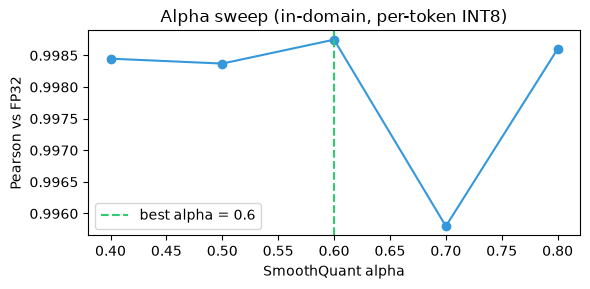

Best alpha = 0.6  (Pearson 0.9987)

In [11]:
sweep = []
for a in ALPHAS:
    m, folds = build_variant(smooth=True, act_mode="per_token", alpha=a)
    fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
    sweep.append((a, fid["pearson"]))
    free(m)

best_alpha = max(sweep, key=lambda t: t[1])[0]
xs, ys = zip(*sweep)

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(xs, ys, "o-", color="#3498DB")
ax.axvline(best_alpha, color="#2ECC71", ls="--", label=f"best alpha = {best_alpha}")
ax.set_xlabel("SmoothQuant alpha")
ax.set_ylabel("Pearson vs FP32")
ax.set_title("Alpha sweep (in-domain, per-token INT8)")
ax.legend()
plt.tight_layout()
plt.show()

rprint(f"[dark_sea_green]Best alpha = {best_alpha}[/dark_sea_green]  (Pearson {dict(sweep)[best_alpha]:.4f})")

## Per-Component Ablation and Mixed Precision

Quantize one projection type at a time (SmoothQuant, per-token, best alpha) to see which costs the most fidelity. The un-smoothed `attn.Wo` and `mlp.Wo` have no preceding `LayerNorm` to absorb a smoothing scale - `mlp.Wo` in particular consumes the GeGLU product - so they are the likely worst offenders. The most damaging component is then held in FP (kept out of the INT8 target set) to test a mixed-precision configuration.

In [12]:
abl_rows = []
for t in QUANT_TARGETS:
    m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=(t,))
    fid = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL)
    abl_rows.append((t, fid["pearson"]))
    free(m)

worst = min(abl_rows, key=lambda r: r[1])[0]      # quantizing this one alone hurts most
mixed_targets = tuple(t for t in QUANT_TARGETS if t != worst)

m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=QUANT_TARGETS)
fid_full = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL); free(m)
m, _ = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=mixed_targets)
fid_mixed = fidelity(emb_fp_dom, sims_fp_dom, m, DOMAIN_EVAL); free(m)

table = Table(title=f"Per-component ablation (solo INT8, alpha={best_alpha})")
table.add_column("only-quantized component", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
for t, p in abl_rows:
    style = "indian_red" if t == worst else "dark_sea_green"
    table.add_row(t, f"[{style}]{p:.4f}[/{style}]")
console.print(table)
rprint(
    f"[steel_blue]Most damaging:[/steel_blue] [indian_red]{worst}[/indian_red]   "
    f"full-INT8 Pearson [dark_sea_green]{fid_full['pearson']:.4f}[/dark_sea_green]  "
    f"vs mixed (keep {worst} FP) [dark_sea_green]{fid_mixed['pearson']:.4f}[/dark_sea_green]"
)

  Per-component ablation (solo INT8,  
              alpha=0.6)              
┏━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┓
┃ only-quantized component ┃ Pearson ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━┩
│ attn.Wqkv                │  0.9995 │
│ attn.Wo                  │  0.9998 │
│ mlp.Wi                   │  0.9997 │
│ mlp.Wo                   │  0.9994 │
└──────────────────────────┴─────────┘

Most damaging: mlp.Wo   full-INT8 Pearson 0.9987  vs mixed (keep mlp.Wo FP) 0.9987

## Chosen Configuration

Picks the deployment configuration: full INT8 unless dropping the worst component to FP buys a meaningful Pearson gain (threshold 0.005, since mixed precision costs one un-quantized projection per layer). The choice and its in-domain plus synthetic fidelity are recorded for Part B and for the embedding stage.

In [13]:
use_mixed = (fid_mixed["pearson"] - fid_full["pearson"]) > 0.005
chosen_targets = mixed_targets if use_mixed else QUANT_TARGETS
chosen_fid_dom = fid_mixed if use_mixed else fid_full

m, folds = build_variant(smooth=True, act_mode="per_token", alpha=best_alpha, targets=chosen_targets)
chosen_fid_syn = fidelity(emb_fp_syn, sims_fp_syn, m, EVAL_SENTENCES)
free(m)

best_config = {
    "model": MODEL_NAME,
    "alpha": best_alpha,
    "act_mode": "per_token",
    "weight_quant": "per_channel_symmetric_int8",
    "targets": list(chosen_targets),
    "mixed_precision": use_mixed,
    "fp_component": worst if use_mixed else None,
    "n_smooth_folds": int(folds),
    "fidelity_in_domain": chosen_fid_dom,
    "fidelity_synthetic": chosen_fid_syn,
}

rprint(f"""[bold medium_purple]Chosen configuration[/bold medium_purple]
[dim]{"─" * 44}[/dim]
  Alpha: [dark_sea_green]{best_alpha}[/dark_sea_green]   Activations: [grey70]per_token[/grey70]
  Mixed precision: [grey70]{use_mixed}[/grey70]{f" (keep {worst} in FP)" if use_mixed else ""}
  In-domain Pearson: [dark_sea_green]{chosen_fid_dom['pearson']:.4f}[/dark_sea_green]   Spearman: [dark_sea_green]{chosen_fid_dom['spearman']:.4f}[/dark_sea_green]
  Synthetic Pearson: [dark_sea_green]{chosen_fid_syn['pearson']:.4f}[/dark_sea_green]
""")

Chosen configuration
────────────────────────────────────────────
  Alpha: 0.6   Activations: per_token
  Mixed precision: False
  In-domain Pearson: 0.9987   Spearman: 0.9987
  Synthetic Pearson: 0.9977

# Part B - Real OpenVINO INT8 Deployment

Part A measured quality by simulation. Part B materializes the chosen configuration as a real, runnable INT8 model so the fidelity gain becomes actual latency and memory savings.

The torch model is converted to OpenVINO with `openvino.convert_model` (architecture-agnostic graph tracing - it sidesteps `optimum-intel`, whose OpenVINO exporter does not yet support the ModernBERT architecture), then quantized to INT8 by **NNCF** with its built-in SmoothQuant at the alpha chosen in Part A, calibrated on the in-domain statements. NNCF re-derives the smoothing scales on the OpenVINO graph, so the real INT8 numbers will differ slightly from the simulation - the verification step below checks they land close. OpenVINO INT8 executes on **CPU** (there is no OV INT8 path on the NVIDIA GPU), matching the deployment target of the project's other quantized models.

## Convert and Quantize

Frees the GPU, converts the FP32 encoder to an OpenVINO graph, and runs NNCF INT8 PTQ with SmoothQuant (`matmul` alpha = the Part A `best_alpha`) on the in-domain calibration set. The deployable IR is written to `models/00-mmbert-openvino-int8/`.

In [14]:
import openvino as ov
import nncf
from nncf.quantization.advanced_parameters import (
    AdvancedQuantizationParameters, AdvancedSmoothQuantParameters,
)

# OpenVINO runs on CPU - free the GPU
model_cpu = copy.deepcopy(model_fp).cpu().eval()
if torch.cuda.is_available():
    model_fp.cpu()
    torch.cuda.empty_cache()


def ov_feed(sents):
    e = tokenizer(
        sents, return_tensors="np", padding="max_length", truncation=True, max_length=MAX_LEN
    )
    return {"input_ids": e["input_ids"], "attention_mask": e["attention_mask"]}


_ex = ov_feed(["a calibration example sentence."])
ov_fp = ov.convert_model(model_cpu, example_input=_ex)

calib_ds = nncf.Dataset([ov_feed([s]) for s in DOMAIN_CALIB])
adv = AdvancedQuantizationParameters(
    smooth_quant_alphas=AdvancedSmoothQuantParameters(matmul=best_alpha)
)
ov_int8 = nncf.quantize(
    ov_fp, calib_ds, model_type=nncf.ModelType.TRANSFORMER,
    advanced_parameters=adv, subset_size=len(DOMAIN_CALIB),
)

OV_DIR.mkdir(parents=True, exist_ok=True)
ov.save_model(ov_int8, str(OV_DIR / "openvino_model.xml"))
tokenizer.save_pretrained(OV_DIR)
rprint(
    f"[dark_sea_green]✓[/dark_sea_green] OpenVINO INT8 (SmoothQuant alpha="
    f"[dark_sea_green]{best_alpha}[/dark_sea_green]) → [dim]{OV_DIR}[/dim]"
)

`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


/home/lab/.local/lib/python3.13/site-packages/transformers/modeling_attn_mask_utils.py:196: TracerWarning: torch.tensor results are registered as constants in the trace. You can safely ignore this warning if you use this function to create tensors out of constant variables that would be the same every time you call this function. In any other case, this might cause the trace to be incorrect.
  inverted_mask = torch.tensor(1.0, dtype=dtype) - expanded_mask


Output()

Output()

Output()

✓ OpenVINO INT8 (SmoothQuant alpha=0.6) → 
/home/lab/workspace/learning/projects/docdistance-estimator/models/00-mmbert-openvino-int8

## Verify Deployed INT8

Embeds both corpora with the real INT8 OpenVINO model on CPU and correlates against the FP32 torch baseline. The question: does the deployed model keep the fidelity the simulation promised? The real Pearson should sit close to the Part A chosen-config number.

In [15]:
core = ov.Core()
cm_fp = core.compile_model(ov_fp, "CPU")
cm_int8 = core.compile_model(ov_int8, "CPU")


def embed_ov(compiled, sents):
    op = compiled.outputs[0]
    vecs = []
    for s in sents:
        e = tokenizer(s, return_tensors="np", padding="max_length", truncation=True, max_length=MAX_LEN)
        r = compiled({"input_ids": e["input_ids"], "attention_mask": e["attention_mask"]})[op]
        mask = e["attention_mask"][..., None].astype("float32")
        v = (r * mask).sum(1) / np.clip(mask.sum(1), 1e-9, None)
        vecs.append((v / np.linalg.norm(v, axis=-1, keepdims=True))[0])
    return torch.tensor(np.stack(vecs))


emb_ov_dom = embed_ov(cm_int8, DOMAIN_EVAL)
sims_ov_dom = pairwise_sims(emb_ov_dom)
real_int8 = {
    "pearson": float(pearsonr(sims_fp_dom, sims_ov_dom)[0]),
    "spearman": float(spearmanr(sims_fp_dom, sims_ov_dom)[0]),
    "emb_cos": float(F.cosine_similarity(emb_fp_dom, emb_ov_dom).mean().item()),
}

table = Table(title="Deployed INT8 vs simulation (in-domain)")
table.add_column("source", style="grey70")
table.add_column("Pearson", style="dark_sea_green", justify="right")
table.add_column("Spearman", style="dark_sea_green", justify="right")
table.add_column("emb cos", style="steel_blue", justify="right")
table.add_row("Part A simulation", f"{chosen_fid_dom['pearson']:.4f}",
              f"{chosen_fid_dom['spearman']:.4f}", f"{chosen_fid_dom['emb_cos']:.4f}")
table.add_row("real OpenVINO INT8", f"{real_int8['pearson']:.4f}",
              f"{real_int8['spearman']:.4f}", f"{real_int8['emb_cos']:.4f}")
console.print(table)

       Deployed INT8 vs simulation (in-domain)       
┏━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━┓
┃ source             ┃ Pearson ┃ Spearman ┃ emb cos ┃
┡━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━┩
│ Part A simulation  │  0.9987 │   0.9987 │  0.9986 │
│ real OpenVINO INT8 │  0.9557 │   0.9826 │  0.9924 │
└────────────────────┴─────────┴──────────┴─────────┘

## Benchmark

Median CPU latency per sentence and on-disk IR size, FP vs INT8. INT8 should be smaller and faster; the exact speedup depends on CPU INT8 kernel support.

In [16]:
import os as _os

sample = DOMAIN_EVAL[: min(16, len(DOMAIN_EVAL))]


def bench(compiled, repeats=5):
    embed_ov(compiled, sample)  # warmup
    ts = []
    for _ in range(repeats):
        t0 = time.perf_counter()
        embed_ov(compiled, sample)
        ts.append(time.perf_counter() - t0)
    return float(np.median(ts)) / len(sample) * 1000.0   # ms / sentence


FP_TMP = Path("/tmp/ov_fp_size")
FP_TMP.mkdir(parents=True, exist_ok=True)
ov.save_model(ov_fp, str(FP_TMP / "openvino_model.xml"))


def ir_size_mb(d):
    return sum(_os.path.getsize(d / f) for f in _os.listdir(d)
               if (d / f).is_file() and f.startswith("openvino_model")) / 1e6


lat_fp, lat_int8 = bench(cm_fp), bench(cm_int8)
mb_fp, mb_int8 = ir_size_mb(FP_TMP), ir_size_mb(OV_DIR)

rprint(f"""[bold medium_purple]OpenVINO CPU benchmark[/bold medium_purple]
[dim]{"─" * 44}[/dim]
  Latency/sentence - FP [light_sea_green]{lat_fp:.1f} ms[/light_sea_green]  →  INT8 [light_sea_green]{lat_int8:.1f} ms[/light_sea_green]  ([dark_sea_green]{lat_fp / lat_int8:.2f}x[/dark_sea_green])
  IR size - FP [light_sea_green]{mb_fp:.0f} MB[/light_sea_green]  →  INT8 [light_sea_green]{mb_int8:.0f} MB[/light_sea_green]  ([dark_sea_green]{mb_fp / mb_int8:.2f}x[/dark_sea_green])
""")

OpenVINO CPU benchmark
────────────────────────────────────────────
  Latency/sentence - FP 29.1 ms  →  INT8 20.6 ms  (1.41x)
  IR size - FP 615 MB  →  INT8 310 MB  (1.98x)

## Save

Writes the full ablation, the chosen configuration, and the real-deployment metrics. `00-mmbert-bestconfig.json` is the record the embedding stage reads to reconstruct the encoder; the metrics JSON is the audit trail of how the configuration was chosen and what the deployed model actually delivers.

In [17]:
metrics = {
    "model": MODEL_NAME,
    "n_params_millions": round(n_params / 1e6, 1),
    "scheme_comparison": [
        {"smoothing": sm, "activations": act, **fid} for sm, act, fid in scheme_rows
    ],
    "alpha_sweep": [{"alpha": a, "pearson": p} for a, p in sweep],
    "best_alpha": best_alpha,
    "component_ablation": [{"component": t, "pearson": p} for t, p in abl_rows],
    "most_damaging_component": worst,
    "chosen_config": best_config,
    "real_openvino_int8": {
        **real_int8,
        "latency_ms_per_sentence_fp": lat_fp,
        "latency_ms_per_sentence_int8": lat_int8,
        "speedup": lat_fp / lat_int8,
        "ir_size_mb_fp": mb_fp,
        "ir_size_mb_int8": mb_int8,
    },
}

METRICS_PATH.parent.mkdir(parents=True, exist_ok=True)
METRICS_PATH.write_text(json.dumps(metrics, indent=2))
BESTCFG_PATH.write_text(json.dumps(best_config, indent=2))

rprint(
    f"[dark_sea_green]✓[/dark_sea_green] metrics → [dim]{METRICS_PATH}[/dim]\n"
    f"[dark_sea_green]✓[/dark_sea_green] best config → [dim]{BESTCFG_PATH}[/dim]\n"
    f"[dark_sea_green]✓[/dark_sea_green] OpenVINO INT8 IR → [dim]{OV_DIR}[/dim]"
)

✓ metrics → 
/home/lab/workspace/learning/projects/docdistance-estimator/reports/00-mmbert-int8-smoothquant-metrics.json
✓ best config → /home/lab/workspace/learning/projects/docdistance-estimator/reports/00-mmbert-bestconfig.json
✓ OpenVINO INT8 IR → /home/lab/workspace/learning/projects/docdistance-estimator/models/00-mmbert-openvino-int8